# Face Defense — Benchmark Evaluation

Anti-Spoofing model benchmark on multiple datasets.

**Models:**
- Silent-FAS (pretrained baseline)
- CDCN (CelebA-Spoof trained, NUAA fine-tuned)

**Datasets:**
- LCC-FASD evaluation set (7,580 images) — cross-dataset
- CelebA-Spoof test set (67,170 images) — same-domain

In [ ]:
import os
import sys
import cv2
import numpy as np
import torch
from tqdm import tqdm

sys.path.insert(0, os.path.abspath(".."))

from antispoof.models.cdcn_model import CDCN
from shared.metrics import (
    compute_auc, compute_eer, compute_apcer, compute_bpcer, compute_acer,
)
from shared.visualization import plot_roc_curve, plot_score_distribution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CDCN(in_channels=3, theta=0.7)
state_dict = torch.load("../checkpoints/cdcn_best.pth", map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print(f"Device: {device}, Model loaded")

## 1. LCC-FASD Cross-Dataset Evaluation (7,580 images)

Evaluate CDCN (trained on CelebA-Spoof) on LCC-FASD evaluation set.

In [2]:
def cdcn_predict(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        depth_map = model(tensor)
    return depth_map.mean().item()

eval_root = "../data/raw/LCC_FASD/LCC_FASD_evaluation"
real_dir = os.path.join(eval_root, "real")
spoof_dir = os.path.join(eval_root, "spoof")

cdcn_labels = []
cdcn_scores = []

for fname in tqdm(sorted(os.listdir(real_dir)), desc="Real"):
    score = cdcn_predict(os.path.join(real_dir, fname))
    if score is not None:
        cdcn_labels.append(1)
        cdcn_scores.append(score)

for fname in tqdm(sorted(os.listdir(spoof_dir)), desc="Spoof"):
    score = cdcn_predict(os.path.join(spoof_dir, fname))
    if score is not None:
        cdcn_labels.append(0)
        cdcn_scores.append(score)

cdcn_labels = np.array(cdcn_labels)
cdcn_scores = np.array(cdcn_scores)
print(f"Evaluated: {len(cdcn_labels)} images ({(cdcn_labels==1).sum()} real, {(cdcn_labels==0).sum()} spoof)")

# Auto detect score direction
real_mean = cdcn_scores[cdcn_labels == 1].mean()
spoof_mean = cdcn_scores[cdcn_labels == 0].mean()
print(f"Real scores  - mean: {real_mean:.4f}")
print(f"Spoof scores - mean: {spoof_mean:.4f}")
if real_mean < spoof_mean:
    print("Score inverted: applying 1 - score")
    cdcn_scores = 1 - cdcn_scores

Spoof: 100%|██████████| 7266/7266 [01:02<00:00, 116.17it/s]

Evaluated: 7580 images (314 real, 7266 spoof)
Real scores  - mean: 0.4153
Spoof scores - mean: 0.7836
Score inverted: applying 1 - score


=== CDCN on LCC-FASD (Cross-Dataset) ===
AUC:   0.8174
EER:   0.2285
APCER: 0.1901
BPCER: 0.3025
ACER:  0.2463


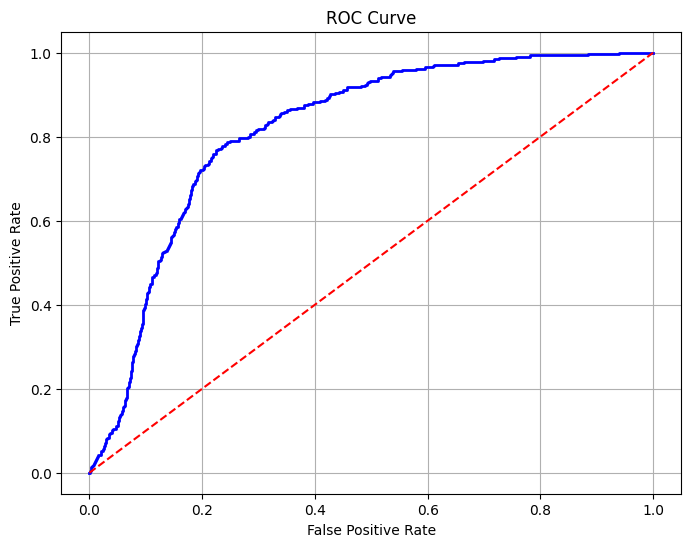

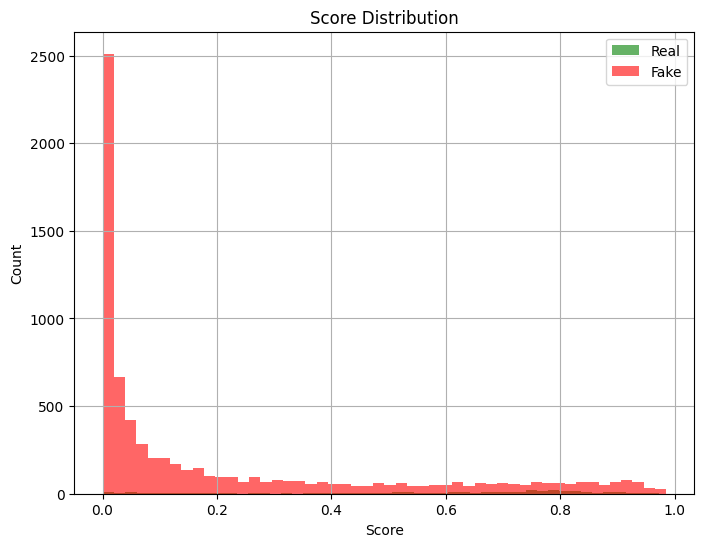

In [3]:
cdcn_preds = (cdcn_scores >= 0.5).astype(int)

print("=== CDCN on LCC-FASD (Cross-Dataset) ===")
print(f"AUC:   {compute_auc(cdcn_labels, cdcn_scores):.4f}")
print(f"EER:   {compute_eer(cdcn_labels, cdcn_scores):.4f}")
print(f"APCER: {compute_apcer(cdcn_labels, cdcn_preds):.4f}")
print(f"BPCER: {compute_bpcer(cdcn_labels, cdcn_preds):.4f}")
print(f"ACER:  {compute_acer(compute_apcer(cdcn_labels, cdcn_preds), compute_bpcer(cdcn_labels, cdcn_preds)):.4f}")

plot_roc_curve(cdcn_labels, cdcn_scores)
plot_score_distribution(cdcn_labels, cdcn_scores)

## 2. CelebA-Spoof Same-Domain Evaluation (67,170 images)

CDCN evaluated on CelebA-Spoof test set (same distribution as training data).
Benchmark run on server (RTX PRO 6000).

| Metric | CDCN |
|--------|------|
| AUC    | 0.9985 |
| EER    | 0.0163 |
| APCER  | 0.0535 |
| BPCER  | 0.0010 |
| ACER   | 0.0272 |

- Real scores: mean 0.9845, std 0.0417
- Spoof scores: mean 0.1123, std 0.1766

## 3. Anti-Spoofing Model Comparison

### LCC-FASD Cross-Dataset (7,580 images, threshold=0.5)

| Metric | Silent-FAS (historical) | CDCN (CelebA-Spoof trained) |
|--------|-------------------------|-----------------------------|
| AUC    | 0.7757                  | **0.8174**                  |
| EER    | 0.3032                  | **0.2285**                  |
| APCER  | 0.2701                  | **0.1901**                  |
| BPCER  | 0.3439                  | **0.3025**                  |
| ACER   | 0.3070                  | **0.2463**                  |

> Silent-FAS numbers are from a prior run before its dependencies were removed (commit `fefcd70`). Kept for historical comparison; not re-runnable in current environment.

### CelebA-Spoof Same-Domain (67,170 images)

| Metric | CDCN |
|--------|------|
| AUC    | **0.9985** |
| EER    | **0.0163** |
| ACER   | **0.0272** |

**AUC**: Classification performance (1.0 = perfect) | **ACER**: Average error rate (lower = better)

## 4. Deepfake Detection (XceptionNet, binary)

Four training iterations from preprocessing-fix through OOD-expansion to maximum-data.

### Overview

| Version | Training data | Best Val | Test ACC | Test AUC |
|---------|---------------|----------|----------|----------|
| **v1** | `ff-c23-frames` (custom extraction) | 0.9235 | 0.5005 | 0.6664 |
| **v2** | `ff-celebdf-frames` train CSV (34k) | 0.9550 | 0.9563 | 0.9929 |
| **v3** | v2 + StyleGAN3 + SDXL + FFHQ (64k) | 0.9716 | 0.9760 | 0.9972 |
| **v3.4** | v3 + WildDeepfake + ff_video + SD1.5 + CelebA-HQ (108k) | 0.9743 | **0.9770** | **0.9967** |

### v1 — preprocessing mismatch

| Split | ACC | AUC | EER |
|-------|-----|-----|-----|
| Overall                 | 0.5005 | 0.6664 | 0.3943 |
| FF++ (in-domain)        | 0.4423 | 0.7085 | 0.3516 |
| Celeb-DF (cross-domain) | 0.5356 | 0.6014 | 0.4401 |

Per-source accuracy revealed a fake-prediction bias:

| Source | ACC | What the model predicted |
|--------|-----|--------------------------|
| ffpp_fake  (n=427)  | 0.9461 | Fake ✓ |
| celeb_fake (n=1674) | 0.9839 | Fake ✓ |
| ffpp_real  (n=1644) | 0.3114 | Mostly fake ✗ |
| celeb_real (n=1752) | 0.1073 | Mostly fake ✗ |

The Val→Test accuracy drop (92% → 50%) is the well-known **preprocessing brittleness** of deepfake detectors.

### v2 — matched preprocessing

| Split | ACC | AUC | EER |
|-------|-----|-----|-----|
| Overall                 | 0.9563 | 0.9929 | 0.0353 |
| FF++                    | 0.9450 | 0.9809 | 0.0633 |
| Celeb-DF                | 0.9632 | 0.9957 | 0.0325 |

Plots: [`plots/roc_v2.png`](../plots/roc_v2.png), [`plots/score_hist_v2.png`](../plots/score_hist_v2.png).

### v3 — OOD expansion (StyleGAN + Diffusion + FFHQ)

| Split | ACC | AUC | EER |
|-------|-----|-----|-----|
| Overall                  | 0.9760 | 0.9972 | 0.0213 |
| face_swap (combined)     | 0.9638 | 0.9941 | 0.0306 |
| StyleGAN holdout         | 0.9990 | — | — |
| Diffusion holdout        | 1.0000 | — | — |
| FFHQ real holdout        | 0.9960 | — | — |

Plots: [`plots/roc_v3.png`](../plots/roc_v3.png), [`plots/score_hist_v3.png`](../plots/score_hist_v3.png).
Training data samples: [`docs/screenshots/v3_data_samples.png`](../docs/screenshots/v3_data_samples.png).

### v3.4 — maximum data (108k, 13 sources)

v3.4 adds WildDeepfake (internet video crops), InsightFace-cropped FF++ video frames, SD 1.5 diffusion, and CelebA-HQ real faces. Training includes compression augmentation (JPEG/blur/downscale) and RandomErasing.

#### Per-split (v3.4 test, 14,997 images)

| Split | ACC | AUC | EER |
|-------|-----|-----|-----|
| Overall                  | **0.9770** | **0.9967** | **0.0218** |
| FF++                     | 0.9594 | 0.9950 | 0.0298 |
| Celeb-DF                 | 0.9700 | 0.9961 | 0.0221 |
| face_swap (combined)     | 0.9609 | 0.9952 | 0.0256 |
| StyleGAN                 | 0.9951 | — | — |
| Diffusion (SDXL)         | 1.0000 | — | — |
| Diffusion (SD 1.5)       | 1.0000 | — | — |
| FFHQ real                | 0.9979 | — | — |
| CelebA-HQ real           | 0.9990 | — | — |
| WildDeepfake             | 0.9980 | — | — |
| FF++ video crops         | 0.9607 | — | — |

#### Per-category progression (v2 → v3 → v3.4)

| Category | v2 ACC | v3 ACC | v3.4 ACC |
|----------|--------|--------|----------|
| face_swap   | 0.9563 | 0.9638 | **0.9609** |
| gan         | 0.0594 | 0.9990 | **0.9951** |
| diffusion   | 0.0099 | 1.0000 | **1.0000** |
| real        | 0.8999 | 0.9960 | **0.9979** |
| WildDeepfake | — | — | **0.9980** |
| ff_video    | — | — | **0.9607** |

Plots: [`plots/roc_v34.png`](../plots/roc_v34.png), [`plots/score_hist_v34.png`](../plots/score_hist_v34.png).

### YouTube video limitation

v3.4 achieves near-perfect accuracy on test images, but real-world YouTube videos remain challenging — h264 re-encoding destroys the subtle artifacts the model relies on. The model is positioned as an **image-level media authenticator**.

### Takeaway

- **v1 → v2** isolates *preprocessing* as the dominant cause of the Val/Test gap.
- **v2 → v3** extends *generator coverage* from face-swap to face-swap + GAN + diffusion (StyleGAN 6%→99.9%, diffusion 1%→100%).
- **v3 → v3.4** maximizes data diversity (64k→108k, 5→13 sources) while maintaining all categories at 96%+.
- **YouTube video** detection remains an open problem due to compression artifact destruction.

## 5. Conclusion

- **Anti-spoofing**: CDCN meets the 5% ACER target at same-domain (2.7%) and outperforms Silent-FAS on cross-dataset.
- **Deepfake (v3.4)**: 97.70% ACC / 0.9967 AUC on 14,997-image test set spanning face-swap, GAN, diffusion, and internet video sources. All categories 96%+.
- **Limitation**: YouTube compressed video detection is unreliable — a known unsolved challenge in deepfake research.
- **Deployment**: IR camera + blink liveness for kiosk; deepfake detection for offline image authentication.